In [1]:
%cd "c:\Users\user\Desktop\younes\data_exploration\uv_project"

c:\Users\user\Desktop\younes\data_exploration\uv_project


In [2]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import calendar
from fpppy.utils import plot_series, plot_series_stacked, plot_diagnostics
from scipy.stats import pearsonr

from coreforecast.scalers import boxcox, boxcox_lambda
from statsmodels.tsa.seasonal import STL, seasonal_decompose

from utilsforecast.plotting import plot_series as plot_series_utils
import tsfeatures as tsf
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

cfg = pl.Config()
cfg.set_tbl_width_chars(10000)
cfg.set_fmt_str_lengths(30)
cfg.set_tbl_cols(-1)
cfg.set_tbl_rows(10)

polars.config.Config

In [3]:
import lib
import importlib
importlib.reload(lib)

current_data, d_one_data = lib.read_smi_situa_journa_distrib4_many()

In [4]:
print(current_data)

shape: (857, 11)
┌────────────┬────────────────────────────────┬──────┬──────┬──────┬──────┬───────┬───────────┬───────────┬──────────┬───────────┐
│ ds         ┆ unique_id                      ┆ nbr1 ┆ nbr3 ┆ nbr6 ┆ nbr8 ┆ nbr10 ┆ nbrreexp1 ┆ nbranoma1 ┆ rnbraffg ┆ Textbox17 │
│ ---        ┆ ---                            ┆ ---  ┆ ---  ┆ ---  ┆ ---  ┆ ---   ┆ ---       ┆ ---       ┆ ---      ┆ ---       │
│ date       ┆ str                            ┆ i64  ┆ i64  ┆ i64  ┆ i64  ┆ i64   ┆ i64       ┆ i64       ┆ i64      ┆ i64       │
╞════════════╪════════════════════════════════╪══════╪══════╪══════╪══════╪═══════╪═══════════╪═══════════╪══════════╪═══════════╡
│ 2024-01-01 ┆ CENTRE COURRIER COLIS LAAYOUNE ┆ 0    ┆ 0    ┆ 0    ┆ 0    ┆ 0     ┆ 0         ┆ 0         ┆ 61       ┆ 0         │
│ 2024-01-02 ┆ CENTRE COURRIER COLIS LAAYOUNE ┆ 307  ┆ 295  ┆ 7    ┆ 0    ┆ 0     ┆ 0         ┆ 0         ┆ 27       ┆ 5         │
│ 2024-01-03 ┆ CENTRE COURRIER COLIS LAAYOUNE ┆ 60   ┆ 58   ┆ 0   

In [5]:
print(d_one_data)

shape: (857, 8)
┌────────────┬────────────────────────────────┬────────┬──────────────┬──────────────┬────────┬───────────────┬────────────┐
│ ds         ┆ unique_id                      ┆ nbraff ┆ nbr_affecomm ┆ nbr_affautre ┆ nbrliv ┆ nbr_ecommerce ┆ nbr_autres │
│ ---        ┆ ---                            ┆ ---    ┆ ---          ┆ ---          ┆ ---    ┆ ---           ┆ ---        │
│ date       ┆ str                            ┆ i64    ┆ i64          ┆ i64          ┆ i64    ┆ i64           ┆ i64        │
╞════════════╪════════════════════════════════╪════════╪══════════════╪══════════════╪════════╪═══════════════╪════════════╡
│ 2024-01-01 ┆ CENTRE COURRIER COLIS LAAYOUNE ┆ 0      ┆ 0            ┆ 0            ┆ 0      ┆ 0             ┆ 0          │
│ 2024-01-02 ┆ CENTRE COURRIER COLIS LAAYOUNE ┆ 299    ┆ 13           ┆ 286          ┆ 292    ┆ 13            ┆ 279        │
│ 2024-01-03 ┆ CENTRE COURRIER COLIS LAAYOUNE ┆ 52     ┆ 0            ┆ 52           ┆ 52     ┆ 0            

In [6]:
current_long = current_data.unpivot(
    index="ds",
    on=pl.selectors.numeric(),
    variable_name="unique_id",
    value_name="y",
)
d_one_long = d_one_data.unpivot(
    index="ds",
    on=pl.selectors.numeric(),
    variable_name="unique_id",
    value_name="y",
)

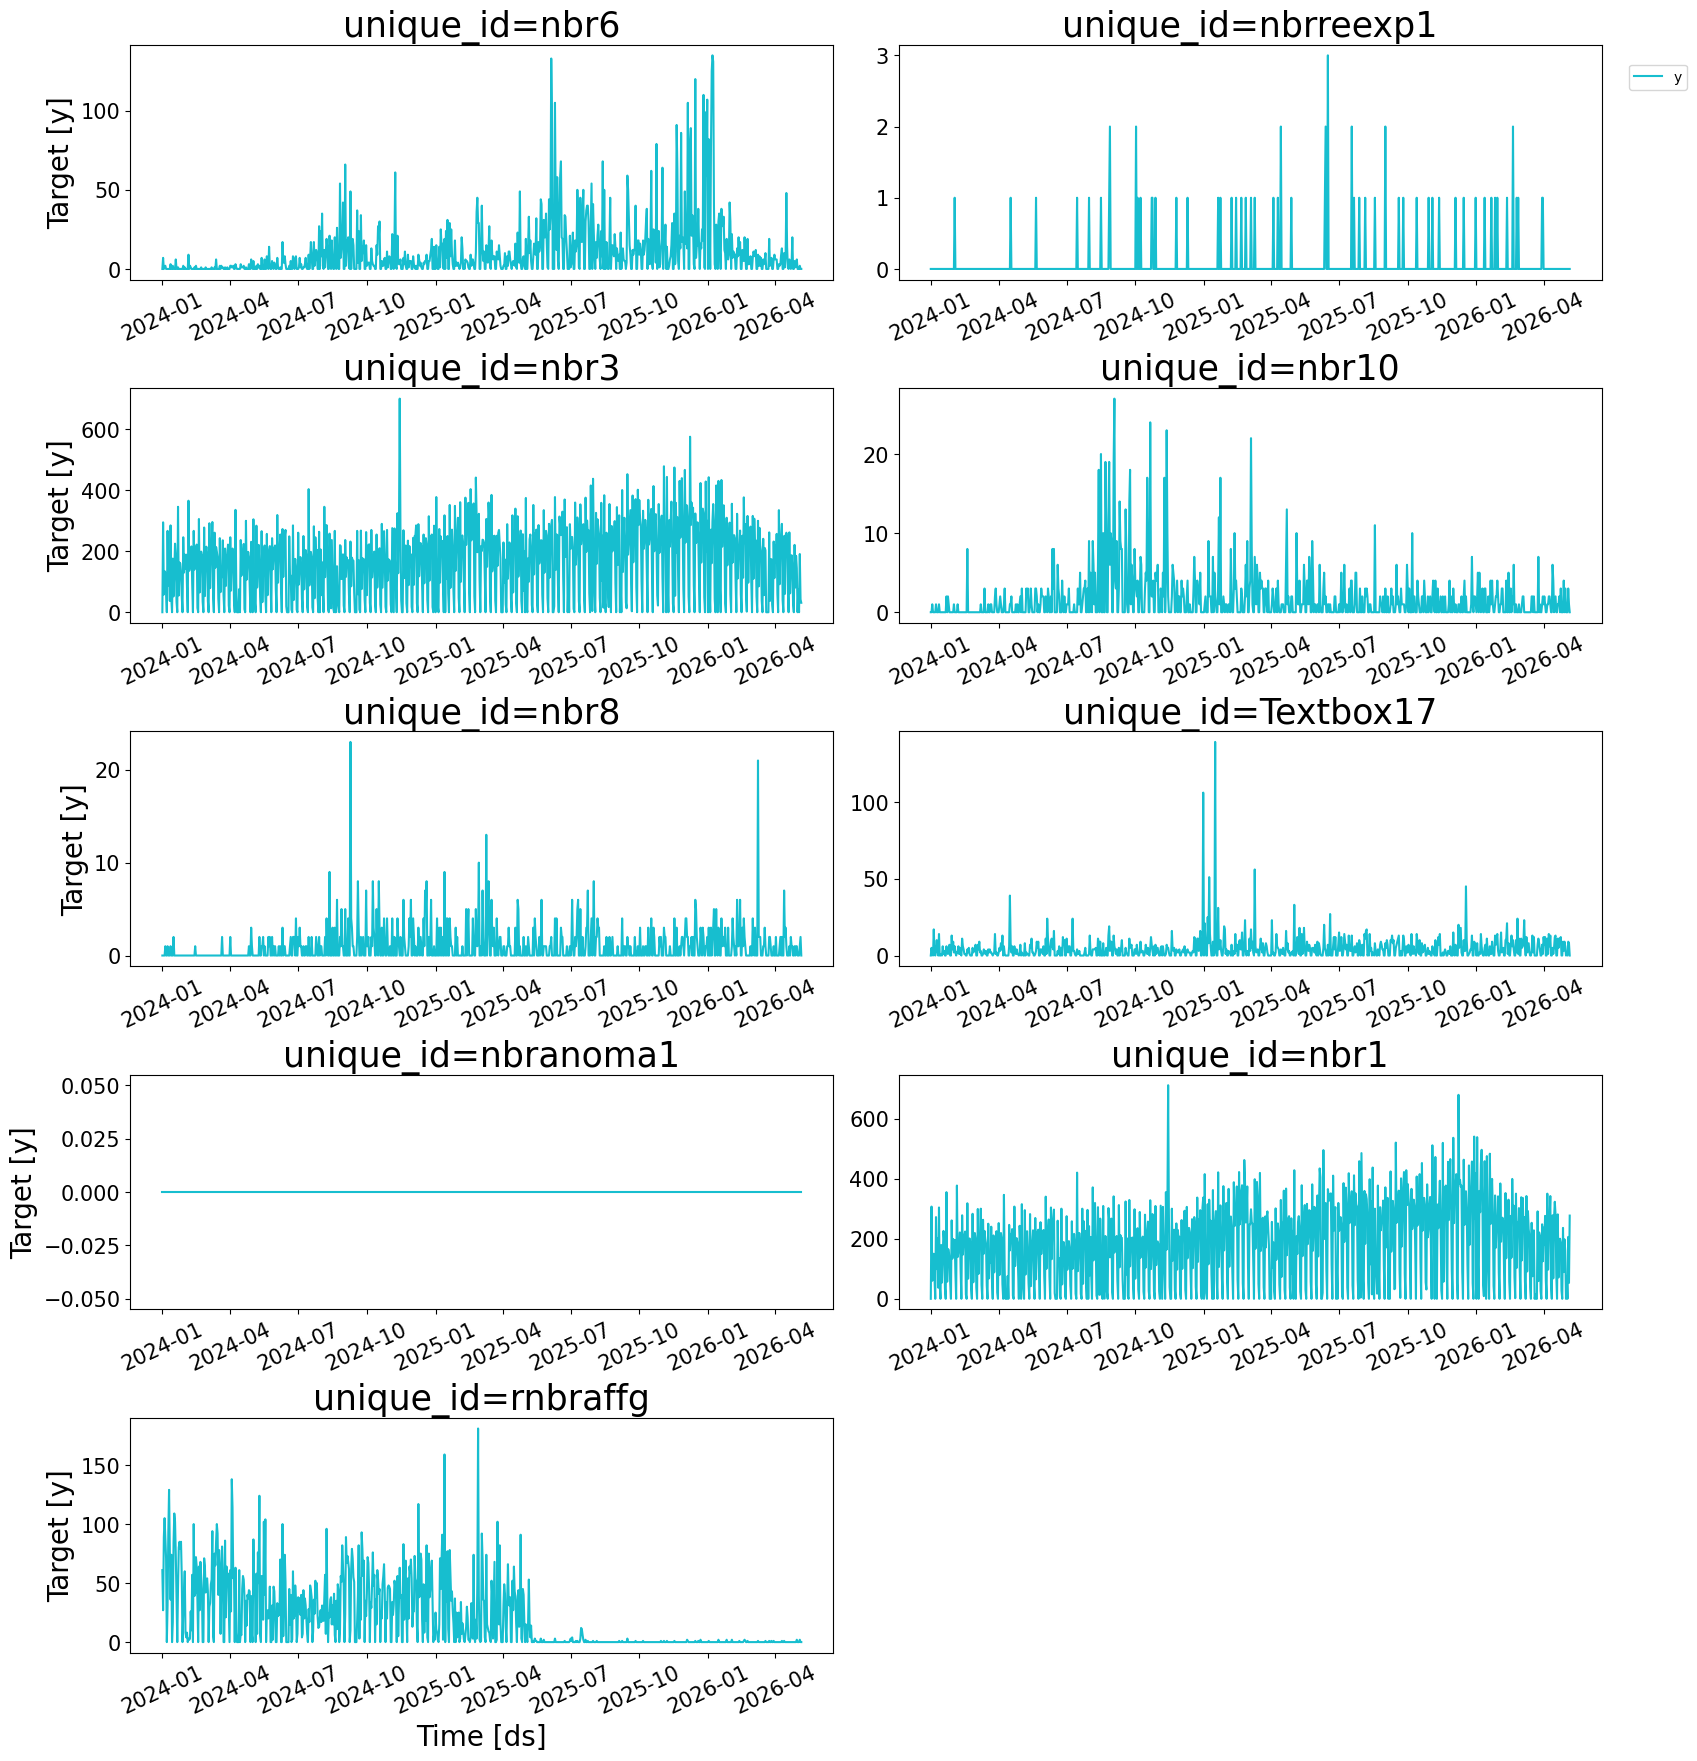

In [7]:
fig = plot_series_stacked(current_long, max_ids=10)

axes = fig.get_axes()
for ax in axes:
    ax.tick_params(axis="x", rotation=25)

fig

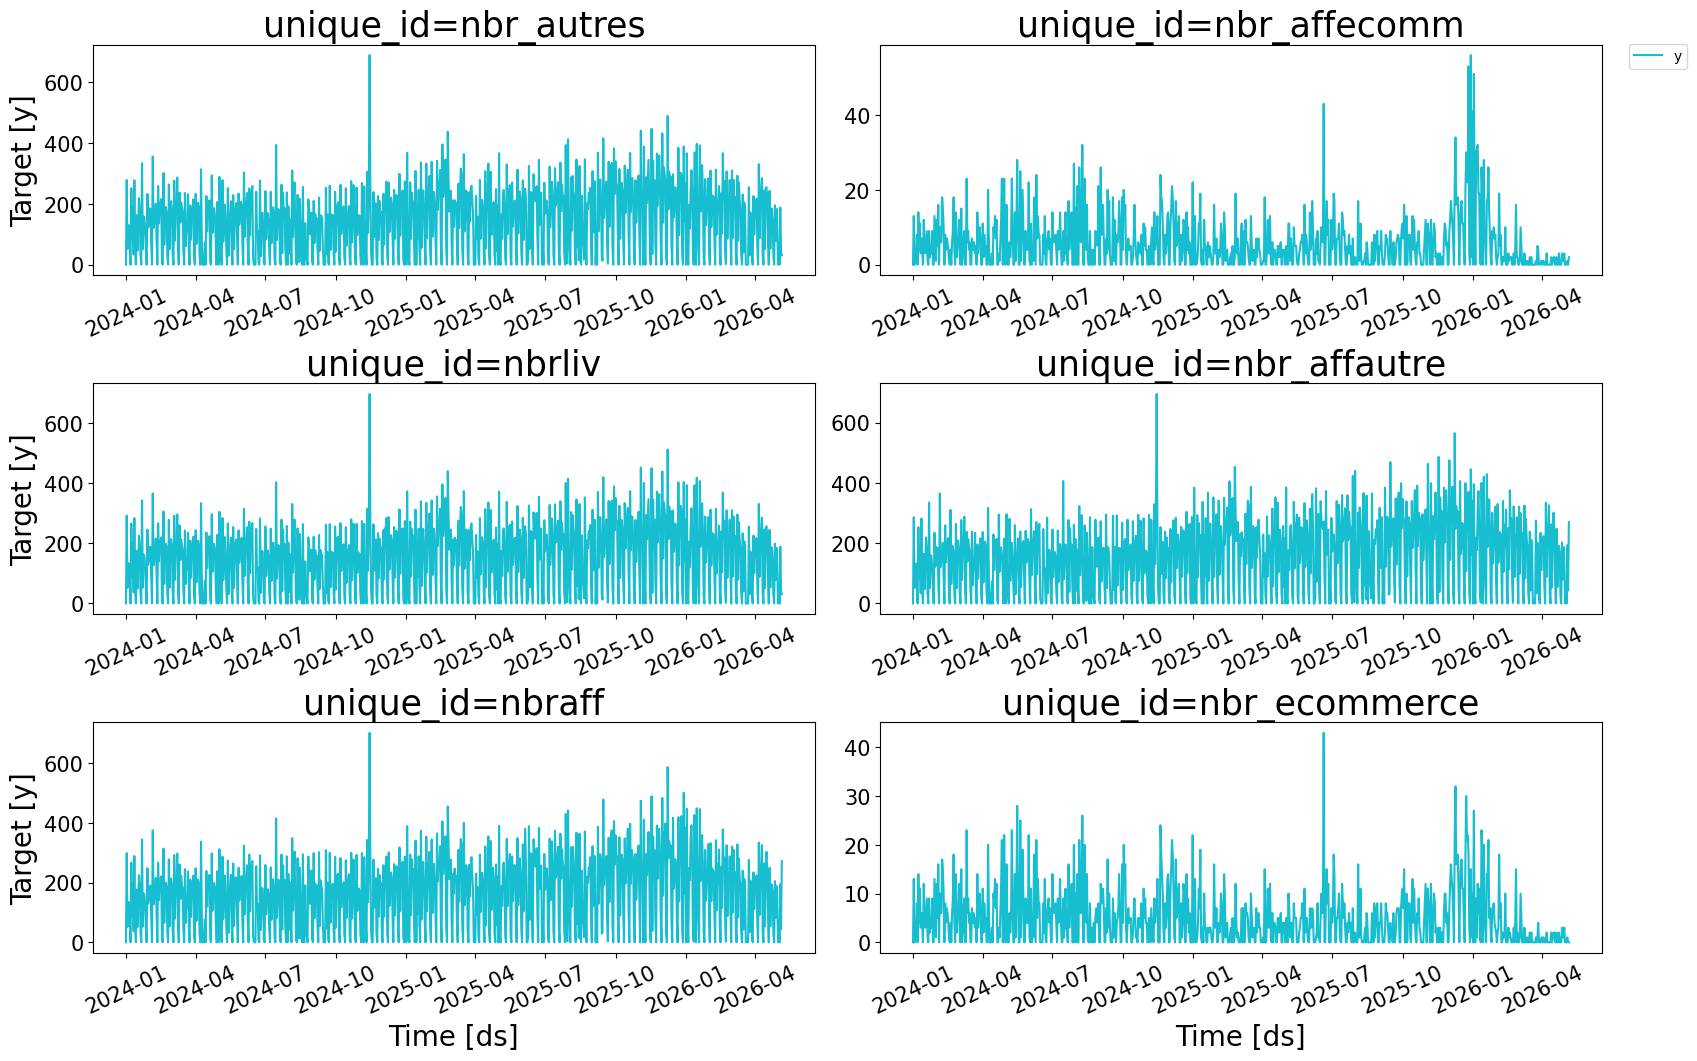

In [8]:
fig = plot_series_stacked(d_one_long)

axes = fig.get_axes()
for ax in axes:
    ax.tick_params(axis="x", rotation=25)

fig

''

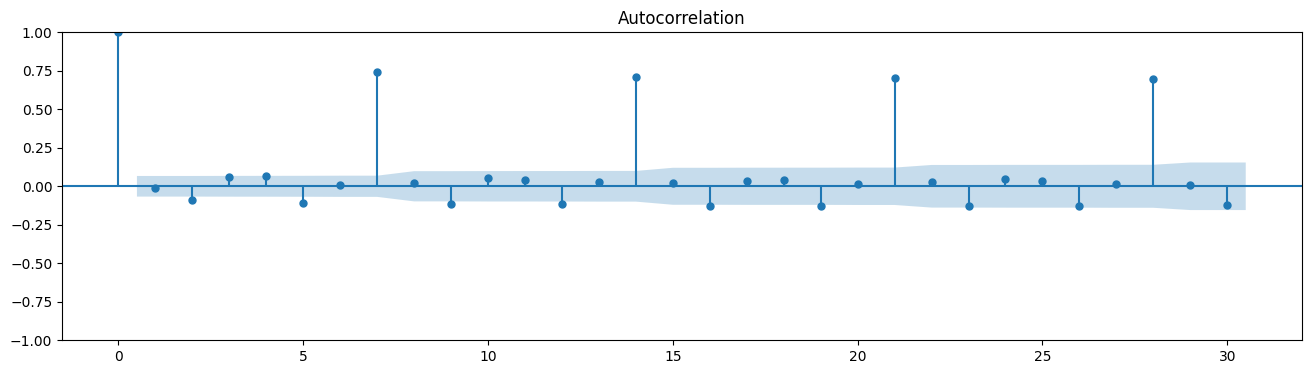

In [9]:
fig, ax = plt.subplots(figsize=(16, 4))
plot_acf(current_data["nbr1"], ax=ax)
""

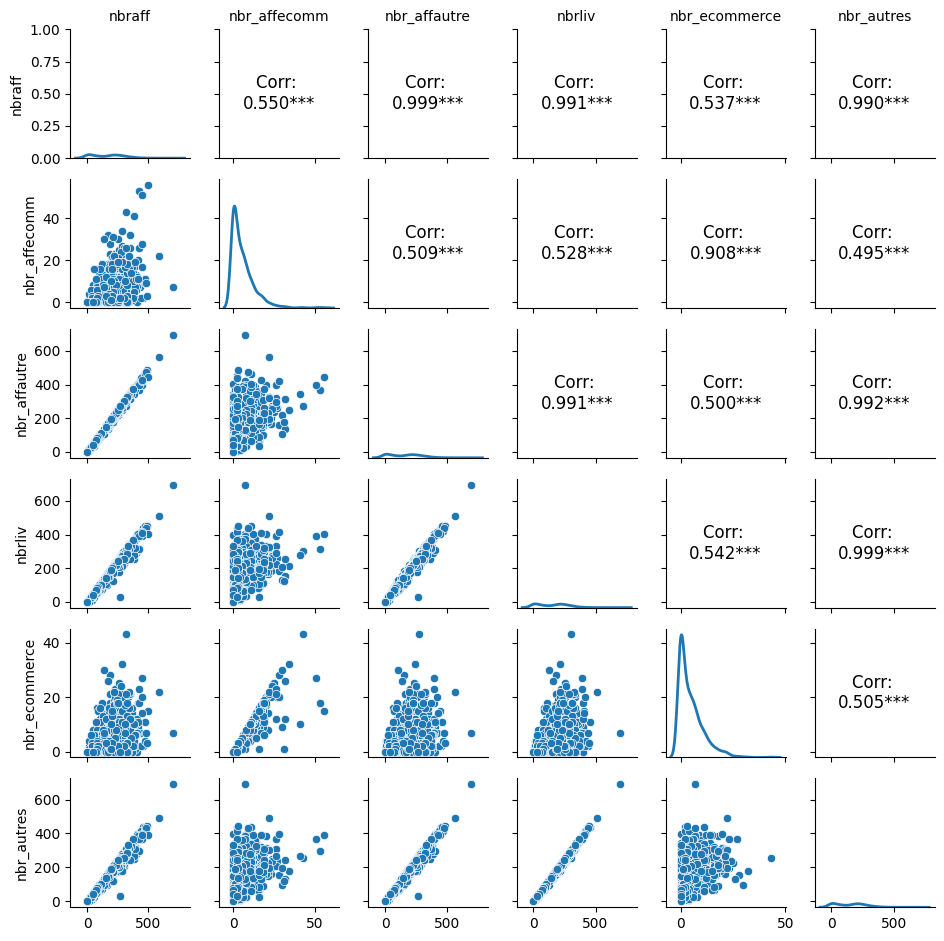

In [10]:
df = d_one_data.select(pl.selectors.numeric()).to_pandas()

def corrfunc(x, y, **kws):
    r, pvalue = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(
        f"Corr: \n{r:.3f}{'***' if pvalue < 0.05 else ''}",
        xy=(0.5, 0.5), xycoords="axes fraction",
        ha="center", va="center", fontsize=12)

g = sns.PairGrid(df, height=1.6)
g.map_lower(sns.scatterplot)
g.map_upper(corrfunc)
g.map_diag(sns.kdeplot, lw=2)
g.set(xlabel="")
for i, col in enumerate(df.columns):
    g.axes[0, i].set_title(col, size="medium")
fig.show()